In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from statsmodels.formula.api import ols
import networkx as nx

### Mediation Analysis

**Mediation Analysis** is a statistical technique that decomposes the **total effect** of $X$ on $Y$ into:

| Effect | Description |
|--------|-------------|
| **Direct Effect** | The effect of $X$ on $Y$ **not** through the mediator ($M$) |
| **Indirect Effect** | The effect of $X$ on $Y$ **through** the mediator ($M$) |


#### The Golden Rule

> **Mediation analysis answers:** *"What is the pathway through which $X$ affects $Y$?"*


#### Visual Representation

```mermaid
graph LR
    subgraph Total["Total Effect"]
        X1[X] -->|"c"| Y1[Y]
    end
    
    subgraph Mediation["Mediation Model"]
        X2[X] -->|"a"| M[M]
        M -->|"b"| Y2[Y]
        X2 -->|"c'"| Y2
    end
```

#### The Equations

| Effect | Formula | Description |
|--------|---------|-------------|
| **Total Effect** | $c = c' + a \times b$ | Overall effect of $X$ on $Y$ |
| **Direct Effect** | $c'$ | Effect of $X$ on $Y$ **not** through $M$ |
| **Indirect Effect** | $a \times b$ | Effect of $X$ on $Y$ **through** $M$ |


#### Visual Representation

```mermaid
graph LR
    X[X] -->|"a"| M[M]
    M -->|"b"| Y[Y]
    X -->|"c'"| Y
    X2[X] -.->|"c = c' + a×b"| Y2[Y]
```

In [2]:
# --- Generate Data ---
np.random.seed(42)
n = 1000

# Treatment: Training program (1 = completed, 0 = not)
training = np.random.binomial(1, 0.5, n)

# Mediator: Skill level (depends on training)
skill = 5 + 3 * training + np.random.normal(0, 1, n)

# Outcome: Productivity (depends on training AND skill)
productivity = 10 + 2 * training + 1.5 * skill + np.random.normal(0, 2, n)

df = pd.DataFrame({
    'Training': training,
    'Skill': skill,
    'Productivity': productivity
})

print("="*60)
print("MEDIATION ANALYSIS: Training → Skill → Productivity")
print("="*60)

# --- Step 1: Total Effect (c) ---
model_total = ols('Productivity ~ Training', data=df).fit()
c = model_total.params['Training']
print(f"\n1. Total Effect (c): {c:.3f}")
print(f"   Interpretation: Training increases productivity by {c:.3f} units total.")

# --- Step 2: Mediator Model (a) ---
model_mediator = ols('Skill ~ Training', data=df).fit()
a = model_mediator.params['Training']
print(f"\n2. Effect of X on M (a): {a:.3f}")
print(f"   Interpretation: Training increases skill by {a:.3f} units.")

# --- Step 3: Outcome Model (c' and b) ---
model_outcome = ols('Productivity ~ Training + Skill', data=df).fit()
c_prime = model_outcome.params['Training']
b = model_outcome.params['Skill']
print(f"\n3. Direct Effect (c'): {c_prime:.3f}")
print(f"   Interpretation: Training directly increases productivity by {c_prime:.3f} units.")
print(f"\n4. Effect of M on Y (b): {b:.3f}")
print(f"   Interpretation: Each unit of skill increases productivity by {b:.3f} units.")

# --- Step 4: Decomposition ---
indirect_effect = a * b
print(f"\n5. Decomposition:")
print(f"   Total Effect (c):          {c:.3f}")
print(f"   Direct Effect (c'):         {c_prime:.3f}")
print(f"   Indirect Effect (a × b):    {indirect_effect:.3f}")
print(f"   Sum (Direct + Indirect):   {c_prime + indirect_effect:.3f}")
print(f"   ✓ Matches Total Effect:    {c:.3f}")

# --- Step 5: Proportion Mediated ---
proportion_mediated = indirect_effect / c
print(f"\n6. Proportion Mediated: {proportion_mediated:.2%}")
print(f"   Interpretation: {proportion_mediated:.1%} of the training effect is through skill improvement.")

MEDIATION ANALYSIS: Training → Skill → Productivity

1. Total Effect (c): 6.601
   Interpretation: Training increases productivity by 6.601 units total.

2. Effect of X on M (a): 2.965
   Interpretation: Training increases skill by 2.965 units.

3. Direct Effect (c'): 2.261
   Interpretation: Training directly increases productivity by 2.261 units.

4. Effect of M on Y (b): 1.464
   Interpretation: Each unit of skill increases productivity by 1.464 units.

5. Decomposition:
   Total Effect (c):          6.601
   Direct Effect (c'):         2.261
   Indirect Effect (a × b):    4.340
   Sum (Direct + Indirect):   6.601
   ✓ Matches Total Effect:    6.601

6. Proportion Mediated: 65.75%
   Interpretation: 65.8% of the training effect is through skill improvement.


### The Sobel Test (Statistical Significance)

The **Sobel Test** checks if the **indirect effect** is statistically significant.


#### What It Tests

| Hypothesis | Meaning |
|------------|---------|
| **Null ($H_0$)** | The indirect effect is **zero** ($a \times b = 0$) |
| **Alternative ($H_1$)** | The indirect effect is **not zero** ($a \times b \neq 0$) |


#### The Formula

$$
z = \frac{a \times b}{\sqrt{b^2 \times SE_a^2 + a^2 \times SE_b^2}}
$$

| Symbol | Meaning |
|--------|---------|
| $a$ | Coefficient for $X \rightarrow M$ |
| $b$ | Coefficient for $M \rightarrow Y$ |
| $SE_a$ | Standard error of $a$ |
| $SE_b$ | Standard error of $b$ |


#### Interpretation

| z-value | p-value | Conclusion |
|---------|---------|------------|
| **> 1.96** | < 0.05 | ✅ Indirect effect is significant |
| **< 1.96** | ≥ 0.05 | ❌ No significant mediation |

In [3]:
from scipy.stats import norm

def sobel_test(a, b, se_a, se_b):
    """
    Sobel Test for mediation significance.
    """
    # Standard error of indirect effect
    se_ab = np.sqrt(se_a**2 * b**2 + se_b**2 * a**2)
    
    # Z-statistic
    z = (a * b) / se_ab
    
    # P-value (two-tailed)
    p_value = 2 * (1 - norm.cdf(abs(z)))
    
    return z, p_value, se_ab

# Get standard errors from the models
se_a = model_mediator.bse['Training']
se_b = model_outcome.bse['Skill']

z, p_value, se_ab = sobel_test(a, b, se_a, se_b)

print(f"\nSobel Test:")
print(f"  Z-statistic: {z:.3f}")
print(f"  P-value: {p_value:.4f}")
print(f"  Standard error of indirect effect: {se_ab:.4f}")

if p_value < 0.05:
    print("  ✅ The indirect effect is statistically significant.")
    print("  → Skill is a significant mediator.")
else:
    print("  ❌ The indirect effect is NOT statistically significant.")
    print("  → No evidence that skill mediates the effect.")


Sobel Test:
  Z-statistic: 21.102
  P-value: 0.0000
  Standard error of indirect effect: 0.2057
  ✅ The indirect effect is statistically significant.
  → Skill is a significant mediator.


C:\Users\rah\AppData\Local\Temp\ipykernel_6564\4196011571.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


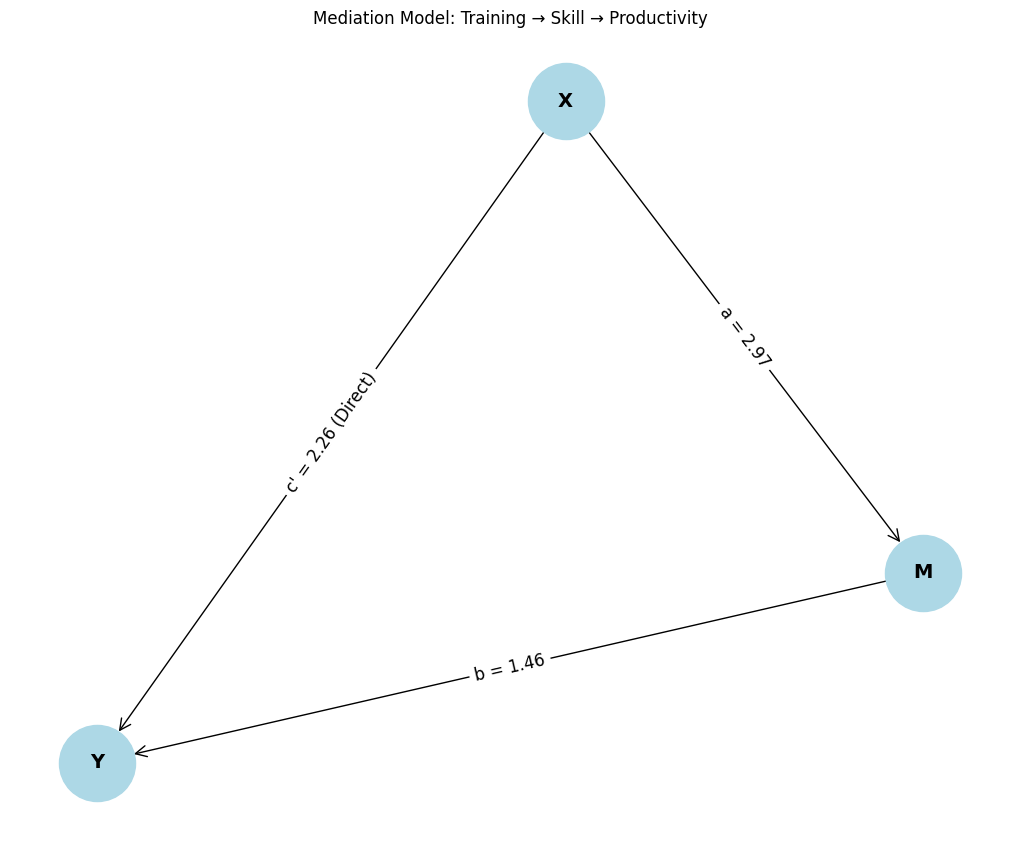

In [5]:
# Create a directed graph
G = nx.DiGraph()

# Add nodes
G.add_nodes_from(['X', 'M', 'Y'])

# Add edges with labels
edges = [
    ('X', 'Y', f'c\' = {c_prime:.2f} (Direct)'),
    ('X', 'M', f'a = {a:.2f}'),
    ('M', 'Y', f'b = {b:.2f}')
]

for edge in edges:
    G.add_edge(edge[0], edge[1], label=edge[2])

# Plot
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(10, 8))

nx.draw(G, pos, with_labels=True, node_color='lightblue', 
        node_size=3000, font_size=14, font_weight='bold',
        arrows=True, arrowsize=20, arrowstyle='->')

# Add edge labels
edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=12)

plt.title('Mediation Model: Training → Skill → Productivity')
plt.axis('off')
plt.tight_layout()
plt.show()

### The ML Connection #4: Types of Mediation

| Type | Definition | Example |
|------|------------|---------|
| **Full Mediation** | No direct effect ($c' \approx 0$) | Training only works through skill |
| **Partial Mediation** | Both direct and indirect effects | Training works through skill **AND** has direct effects |
| **Suppression** | Direct and indirect have opposite signs | Training directly reduces productivity but improves skill |
| **Mediation with Interaction** | The mediator interacts with the treatment | Training effect depends on skill level |

In [6]:
def demonstrate_mediation_types():
    """
    Show the difference between full and partial mediation.
    """
    np.random.seed(42)
    n = 1000
    
    # Full Mediation (no direct effect)
    X_full = np.random.binomial(1, 0.5, n)
    M_full = 5 + 3 * X_full + np.random.normal(0, 1, n)
    Y_full = 10 + 1.5 * M_full + np.random.normal(0, 2, n)  # No direct effect of X!
    
    # Partial Mediation (direct + indirect)
    X_partial = np.random.binomial(1, 0.5, n)
    M_partial = 5 + 3 * X_partial + np.random.normal(0, 1, n)
    Y_partial = 10 + 2 * X_partial + 1.5 * M_partial + np.random.normal(0, 2, n)
    
    print("="*60)
    print("FULL vs PARTIAL MEDIATION")
    print("="*60)
    
    # Full Mediation
    model_full_total = ols('Y ~ X', data=pd.DataFrame({'X': X_full, 'Y': Y_full, 'M': M_full})).fit()
    model_full_mediator = ols('M ~ X', data=pd.DataFrame({'X': X_full, 'M': M_full})).fit()
    model_full_outcome = ols('Y ~ X + M', data=pd.DataFrame({'X': X_full, 'Y': Y_full, 'M': M_full})).fit()
    
    print("\nFull Mediation:")
    print(f"  Total Effect (c): {model_full_total.params['X']:.3f}")
    print(f"  Direct Effect (c'): {model_full_outcome.params['X']:.3f}")
    print(f"  Indirect Effect: {model_full_total.params['X'] - model_full_outcome.params['X']:.3f}")
    
    # Partial Mediation
    model_partial_total = ols('Y ~ X', data=pd.DataFrame({'X': X_partial, 'Y': Y_partial, 'M': M_partial})).fit()
    model_partial_mediator = ols('M ~ X', data=pd.DataFrame({'X': X_partial, 'M': M_partial})).fit()
    model_partial_outcome = ols('Y ~ X + M', data=pd.DataFrame({'X': X_partial, 'Y': Y_partial, 'M': M_partial})).fit()
    
    print("\nPartial Mediation:")
    print(f"  Total Effect (c): {model_partial_total.params['X']:.3f}")
    print(f"  Direct Effect (c'): {model_partial_outcome.params['X']:.3f}")
    print(f"  Indirect Effect: {model_partial_total.params['X'] - model_partial_outcome.params['X']:.3f}")

demonstrate_mediation_types()

FULL vs PARTIAL MEDIATION

Full Mediation:
  Total Effect (c): 4.601
  Direct Effect (c'): 0.261
  Indirect Effect: 4.340

Partial Mediation:
  Total Effect (c): 6.474
  Direct Effect (c'): 2.049
  Indirect Effect: 4.425


### Mediation Analysis: Key Terms

| Term | Definition | Formula |
|------|------------|---------|
| **Total Effect** | Overall effect of $X$ on $Y$ | $c$ |
| **Direct Effect** | Effect of $X$ on $Y$ not through $M$ | $c'$ |
| **Indirect Effect** | Effect of $X$ on $Y$ through $M$ | $a \times b$ |
| **Proportion Mediated** | % of total effect explained by $M$ | $(a \times b) / c$ |
| **Full Mediation** | $c' \approx 0$ | No direct effect |
| **Partial Mediation** | Both $c'$ and $a \times b > 0$ | Both direct and indirect |
